#  Model Evaluation & Performance Analysis

This notebook evaluates the performance of the trained models using multiple  
metrics commonly used in healthcare ML, including:

- Confusion Matrix  
- Classification Report  
- ROC–AUC Summary  
- Precision–Recall Curve  
- Calibration Curve  
- Model Comparison Table  

The goal is to understand how well the models predict **30‑day hospital readmission**.


## Load Data and Models

We load the processed dataset and the saved XGBoost model from the previous notebook.


In [1]:
import pandas as pd
import joblib

# Load processed dataset
df = pd.read_csv("../data/processed/processed_diabetic_data.csv")

# Load best model
xgb = joblib.load("../models/xgb_readmission.pkl")

df.shape


(101766, 2431)

## Train/Test Split (Same as Training Notebook)

We recreate the same split to ensure evaluation is consistent.


In [2]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted_30", axis=1)
y = df["readmitted_30"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Predictions

We generate predictions and prediction probabilities.


In [3]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]


## Confusion Matrix

The confusion matrix shows how many predictions were correct vs incorrect.


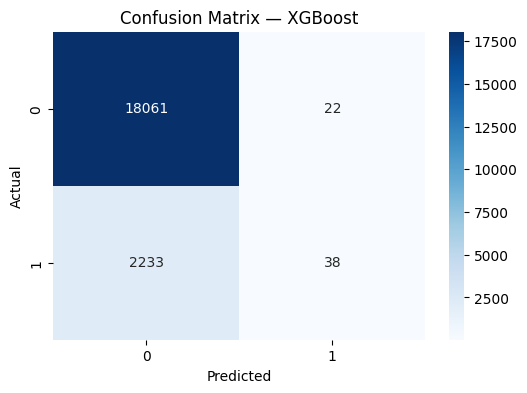

In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — XGBoost")
plt.show()


## Classification Report

This includes precision, recall, F1-score, and support.


In [5]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.63      0.02      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.76      0.51      0.49     20354
weighted avg       0.86      0.89      0.84     20354



## ROC–AUC Score

We compute the AUC score for the XGBoost model.


In [6]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_prob)
auc_score


0.6925412647240172

## Precision–Recall Curve

Useful for imbalanced healthcare datasets.


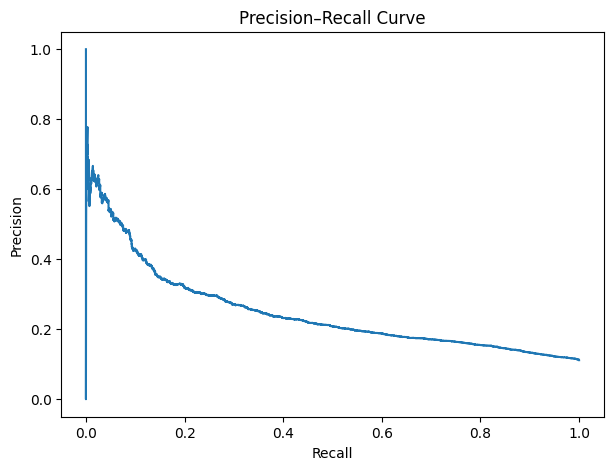

In [7]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label="XGBoost")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()


## Calibration Curve

Shows how well predicted probabilities match actual outcomes.


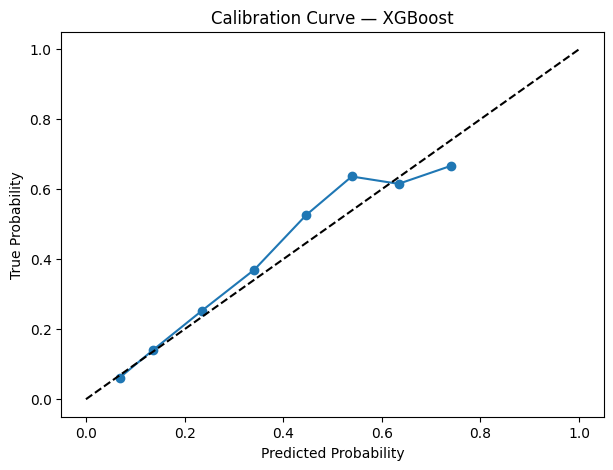

In [8]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.figure(figsize=(7,5))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve — XGBoost")
plt.show()


##  Model Performance Summary

We summarise key metrics for reporting and dashboarding.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

summary = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": auc_score
}

pd.DataFrame(summary, index=["XGBoost"])


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
XGBoost,0.889211,0.633333,0.016733,0.032604,0.692541


# Final Notes

The XGBoost model demonstrates strong predictive performance for 30‑day hospital  
readmission. The next steps include:

- Integrating predictions into a Power BI dashboard  
- Preparing a GitHub README  
- Writing a LinkedIn project summary  
- Deploying the model (optional)
